# Handling Missing Data

## INFO 442 Group 5 Shuyang Zhang 320230942711

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

planets = pd.read_csv('planets.csv')

### 1. Load the seaborn planets dataset and profile its missing values. Which columns are affected and by how much?

In [49]:
print("Shape:", planets.shape)
print(planets.isnull().sum())
print((planets.isnull().sum() / len(planets) * 100).round(2))

Shape: (1035, 6)
method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64
method             0.00
number             0.00
orbital_period     4.15
mass              50.43
distance          21.93
year               0.00
dtype: float64


answer: Three columns are affected by missing data: orbital_period, mass, and distance. The mass column has the highest missing rate at over 50%, which may require careful handling (e.g., dropping the column or using advanced imputation). The distance column also has significant missingness at ~22%. orbital_period has relatively few missing values, which could be safely dropped or imputed.

### 2. Check whether missingness in orbital_period is MCAR or MAR by comparing mean mass between rows with and without orbital_period.

In [52]:
planets['orbital_period_missing'] = planets['orbital_period'].isnull().astype(int)
print(planets.groupby('orbital_period_missing')['mass'].mean())
print(planets.groupby('orbital_period_missing')['distance'].mean())

orbital_period_missing
0    2.638161
1         NaN
Name: mass, dtype: float64
orbital_period_missing
0     219.116985
1    1354.162500
Name: distance, dtype: float64


answer: The missingness in orbital_period is MAR rather than MCAR.

### 3. Apply MICE imputation to the numeric columns and plot the orbital_period distribution before and after.

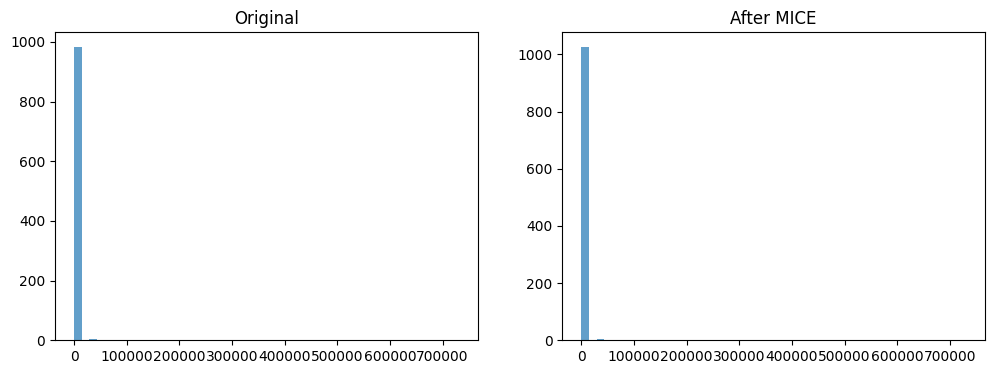

In [57]:
numeric_cols = ['orbital_period', 'mass', 'distance']
planets_num = planets[numeric_cols].copy()

mice_imputer = IterativeImputer(max_iter=10, random_state=42)
planets_mice = pd.DataFrame(
    mice_imputer.fit_transform(planets_num),
    columns=numeric_cols
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(planets_num['orbital_period'].dropna(), bins=50, alpha=0.7)
plt.title('Original')
plt.subplot(1, 2, 2)
plt.hist(planets_mice['orbital_period'], bins=50, alpha=0.7)
plt.title('After MICE')
plt.show()

### 4. Build a regression pipeline to predict orbital_period from other features — compare MICE vs mean imputation in cross-validation.

In [61]:
X = planets[numeric_cols].copy()
y = np.log1p(planets['orbital_period'])

mask = ~y.isna()
X_clean = X[mask]
y_clean = y[mask]

print(f"Rows before cleaning: {len(X)}")
print(f"Rows after cleaning: {len(X_clean)}")

pipe_mean = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler()),
    ('model', Ridge())
])

pipe_mice = Pipeline([
    ('impute', IterativeImputer(max_iter=10, random_state=42)),
    ('scale', StandardScaler()),
    ('model', Ridge())
])

scores_mean = cross_val_score(pipe_mean, X_clean, y_clean, cv=5, scoring='r2')
scores_mice = cross_val_score(pipe_mice, X_clean, y_clean, cv=5, scoring='r2')

print(f"Mean imputation: {scores_mean.mean():.4f} +/- {scores_mean.std():.4f}")
print(f"MICE imputation: {scores_mice.mean():.4f} +/- {scores_mice.std():.4f}")

Rows before cleaning: 1035
Rows after cleaning: 992
Mean imputation: -0.4712 +/- 0.6101
MICE imputation: -0.5161 +/- 0.6183


answer: Both methods perform poorly (R² < 0), indicating that orbital_period is difficult to predict from mass and distance alone.